In [1]:
import torch
from PIL import Image, ImageFilter
from diffusers import StableDiffusionInpaintPipeline, AutoencoderKL
from torch.utils.tensorboard import SummaryWriter
import datetime

state = {
    "shift": (0, 0), # memorizzo dx e dy per unrolling
    "has_replicated": False # sono al 60%? -> Latent replication
}

def callback(pipe, step_index, timestep, callback_kwargs):
    global state
    latents = callback_kwargs["latents"] # rumore
    mask = callback_kwargs["mask"] # maschera
    image = callback_kwargs["masked_image_latents"] #immagine in input
    num_steps = len(pipe.scheduler.timesteps) #step totali

    # Sono al 60% -> Replication
    if not state["has_replicated"] and step_index >= int(num_steps * 0.6):
        # incollo x4: 512 ->1024
        latents = latents.repeat(1, 1, 2, 2)
        mask = mask.repeat(1, 1, 2, 2)
        image = image.repeat(1, 1, 2, 2)
        
        state["has_replicated"] = True
        print(f"Latent Replication allo step {step_index}")

    # Unrolling
    if state["shift"] != (0, 0):
        sx, sy = state["shift"]

        latents = torch.roll(latents, shifts=(-sy, -sx), dims=(-2, -1))
        mask = torch.roll(mask, shifts=(-sy, -sx), dims=(-2, -1))
        image = torch.roll(image, shifts=(-sy, -sx), dims=(-2, -1))

    # Rolling
    if step_index < num_steps - 1:

        # dx dy casuali tra 0 e lunghezza o altezza immagine
        new_dx = torch.randint(0, latents.shape[-1], (1,)).item()
        new_dy = torch.randint(0, latents.shape[-2], (1,)).item()
        
        # shift
        latents = torch.roll(latents, shifts=(new_dy, new_dx), dims=(-2, -1)) #-2 asse x, -1 asse y
        mask = torch.roll(mask, shifts=(new_dy, new_dx), dims=(-2, -1))
        image = torch.roll(image, shifts=(new_dy, new_dx), dims=(-2, -1))
    
        state["shift"] = (new_dx, new_dy)
    else:
        state["shift"] = (0, 0)

    # Restituisco tensori a sd
    callback_kwargs["latents"] = latents
    callback_kwargs["mask"] = mask
    callback_kwargs["masked_image_latents"] = image

    return callback_kwargs

/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/torch/cuda/__init__.py:546: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
log_dir = "runs/esperimento_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir)

device = "cuda"
model_id = "sd-legacy/stable-diffusion-inpainting"
adapter_id = "h94/IP-Adapter"

In [3]:
vae = AutoencoderKL.from_pretrained(
    "stabilityai/sd-vae-ft-mse",
    torch_dtype=torch.float16
).to(device)

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id, 
    use_safetensors=False,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
    vae = vae
).to(device)

#pipe.enable_model_cpu_offload()
#pipe.enable_attention_slicing()

#pipe.vae.enable_tiling()

/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Loading pipeline components...: 100%|██████████| 6/6 [00:02<00:00,  2.36it/s]


In [4]:
def patch_conv_circular(model):
    for layer in model.modules():
        if isinstance(layer, torch.nn.Conv2d):
            layer.padding_mode = 'circular'

patch_conv_circular(pipe.unet)

In [5]:
from diffusers import DDIMScheduler
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

In [6]:
pipe.load_ip_adapter(adapter_id, subfolder="models", weight_name="ip-adapter_sd15.bin")
pipe.set_ip_adapter_scale(0.8)

#print(torch.cuda.memory.memory_summary(device=device, abbreviated=False))
#pipe.to(device)
#print(torch.cuda.memory.memory_summary(device=device, abbreviated=False))

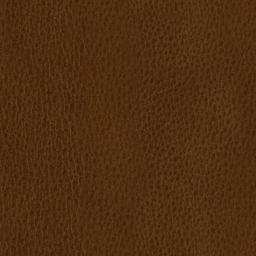

In [7]:
BASE_SIZE = 512
INNER_SIZE = 256
OFFSET = (BASE_SIZE - INNER_SIZE) // 2 

try:
    input_image = Image.open("leather.jpg").convert("RGB")
    width, height = input_image.size

    left = (width - BASE_SIZE) / 2
    top = (height - BASE_SIZE) / 2
    right = (width + BASE_SIZE) / 2
    bottom = (height + BASE_SIZE) / 2
    input_image = input_image.crop((left, top, right, bottom))
    small_texture = input_image.resize((256,256))

except:
    print("Immagine non trovata.")
    small_texture = Image.new("RGB", (INNER_SIZE, INNER_SIZE), "red")

small_texture.save("prova_1cropped_2.png")
display(small_texture)
#display(input_image)

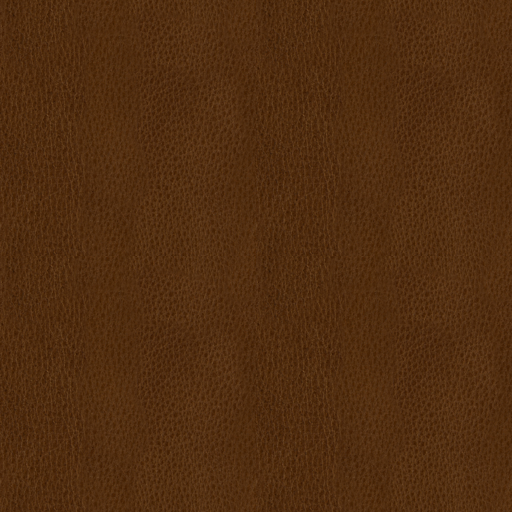

In [8]:
bg_hint = Image.new("RGB", (BASE_SIZE, BASE_SIZE), "white") 
canvas = bg_hint.copy()
canvas.paste(small_texture, (OFFSET, OFFSET))

mask = Image.new("L", (BASE_SIZE, BASE_SIZE), 255)
mask_center = Image.new("L", (INNER_SIZE, INNER_SIZE), 0)
mask.paste(mask_center, (OFFSET, OFFSET))
mask = mask.filter(ImageFilter.GaussianBlur(radius=3)) 

def create_guidance_image(source_img, target_size):
    tiled_bg = Image.new("RGB", (target_size, target_size))
    w, h = source_img.size
    tile_w, tile_h = 256, 256
    source_resized = source_img.resize((tile_w, tile_h))
    for i in range(0, target_size, tile_w):
        for j in range(0, target_size, tile_h):
            tiled_bg.paste(source_resized, (i, j))
    return tiled_bg


ip_adapter_image = create_guidance_image(small_texture, BASE_SIZE) 

ip_adapter_image.save("prova_2guidance_2.png")
display(ip_adapter_image)

 62%|██████▏   | 31/50 [01:40<01:01,  3.25s/it]

Latent Replication allo step 30


100%|██████████| 50/50 [18:09<00:00, 21.79s/it]


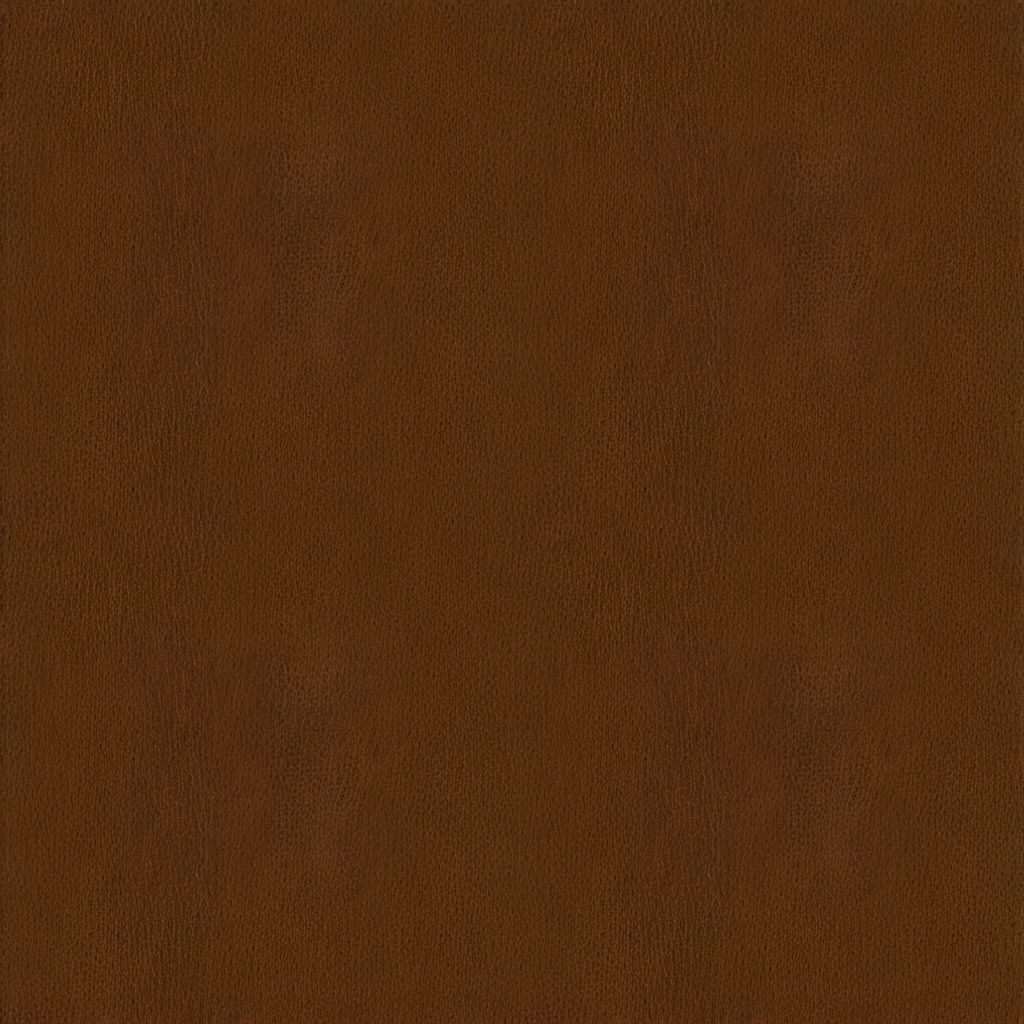

In [9]:
state["shift"] = (0, 0)
prompt = "Raw texture, regular pattern, flat colors, macro photography, close up, rough surface, hyperrealistic, top down view"
negative_prompt = "cartoon, drawing, painting, flat colors, vector, illustration, blurry, smooth, deformed, noisy"

output_base = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=canvas, 
    mask_image=mask,
    ip_adapter_image=ip_adapter_image,
    num_inference_steps=50,
    guidance_scale=7.5,
    callback_on_step_end=callback, # chiama la callback alla fine di ogni step
    callback_on_step_end_tensor_inputs=["latents", "mask", "masked_image_latents"] # input callback
).images[0]

display(output_base)

output_base.save("prova_3risultato_512_2.png")